# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


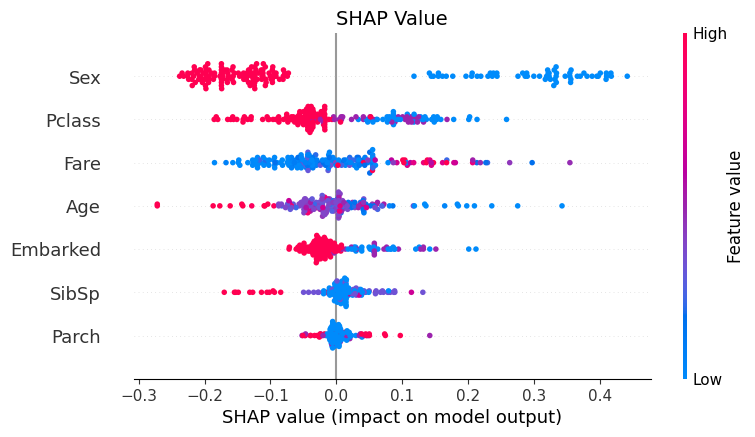

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

In [5]:
# 데이터 로드
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna # 하이퍼파라미터(모델 설정값) 자동 탐색기
import shap # shap value: ai의 예측 결과에 대해 어떤 데이터가 
# 긍정(+) 혹은 부정적(-)으로, 얼마나 강력하게 영향을 미쳤는지를 설명
import matplotlib.pyplot as plt
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# <은행 고객 이탈 예측 데이터>
# credit_score (신용 점수)
# tenure (거래 기간)
# balance (계좌 잔액)
# estimated_salary (추정 연봉)
# products_number (이용 상품 수)
# credit_card (신용카드 보유 여부)
# active_member (활성 고객 여부)
# churn (이탈 여부)-> y로 선정
# -1은 이탈, 0은 이탈 아님

In [16]:
df.info()
# 결측치는 존재하지 않음
# 범주형: 'country', 'gender' 나머지는 수치형

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [17]:
df.describe().round()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,15690941.0,651.0,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0
std,71936.0,97.0,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0
min,15565701.0,350.0,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0
25%,15628528.0,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0
50%,15690738.0,652.0,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0
75%,15753234.0,718.0,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0
max,15815690.0,850.0,92.0,10.0,250898.0,4.0,1.0,1.0,199992.0,1.0


In [18]:
# 단변량 분석(y)
df['churn'].value_counts(normalize=True)
# 이탈 여부를 측정했을 때 이탈X가 약 80%로 훨씬 많은 것을 파악해볼 수 있음.

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64

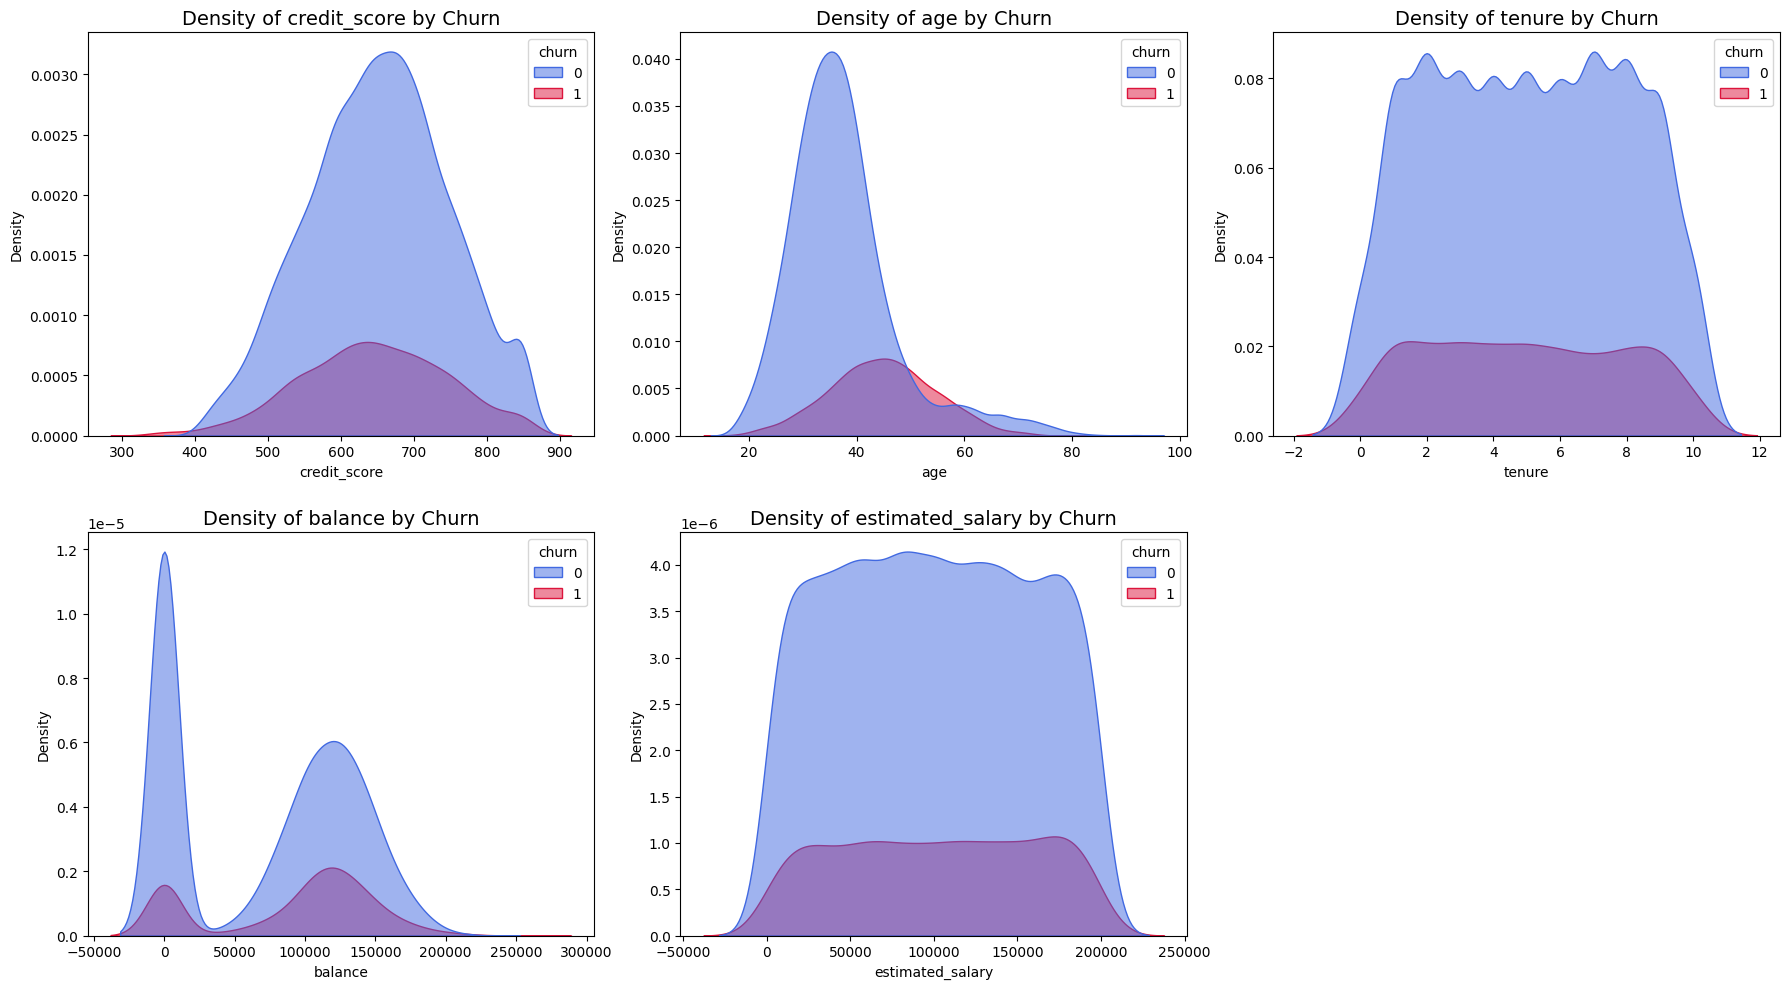

In [12]:
# (1) 이변량 분석(수치형-수치형)-> 단순 시각화
# 분석할 수치형 변수 리스트
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

# 2행 3열 도화지 세팅 (총 6칸 중 5칸 사용)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # 다루기 쉽게 1차원 배열로 쫙 펴주기

for i, col in enumerate(num_cols):
    # 밀도 그래프 그리기
    # fill=True로 안을 채우고, alpha로 투명도 조절해서 겹치는 부분 보이게 함
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, 
                palette={0: 'royalblue', 1: 'crimson'}, alpha=0.5, ax=axes[i])
    
    axes[i].set_title(f'Density of {col} by Churn', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# 남는 6번째 빈 그래프 공간은 깔끔하게 숨기기
axes[5].axis('off')

# 그래프 간격 자동 조절
plt.tight_layout()
plt.show()


# 분석 결과  
1. credit_score: 두 그래프가 거의 겹치기 때문에, 신용 점수와 이탈율은 관계가 크다고 볼 가능성이 적다.  
2. age: 파란색 봉우리는 30대에 솟아 있고, 빨간색 봉우리는 40~50대에 솟아 있는 것을 보아, 나이가 많을수록 이탈율이 더 높다고 볼 가능성이 있다.  
3. tenure: 두 그래프가 겹치는 경향이 있어, 거래 기간과 이탈율은 관계가 크다고 볼 가능성이 적다.  
4. balance: 잔고가 0인 그룹과, 잔고가 있는 그룹을 나눠서 분석할 필요성이 있다고 느껴진다.  
5. estimated_salary: 두 그래프가 거의 겹치기 때문에, 추정 연봉과 이탈율은 관계가 크다고 볼 가능성이 적다.  

-> age는 이탈율을 예측하는데 중요한 변수로 쓰일 가능성이 있다.

C:\Users\young\AppData\Local\Temp\ipykernel_1144\1197190447.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i, 1], palette='Set2')
C:\Users\young\AppData\Local\Temp\ipykernel_1144\1197190447.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i, 1], palette='Set2')
C:\Users\young\AppData\Local\Temp\ipykernel_1144\1197190447.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='churn', data=df, ax=axes[i, 1], palette='Set2')


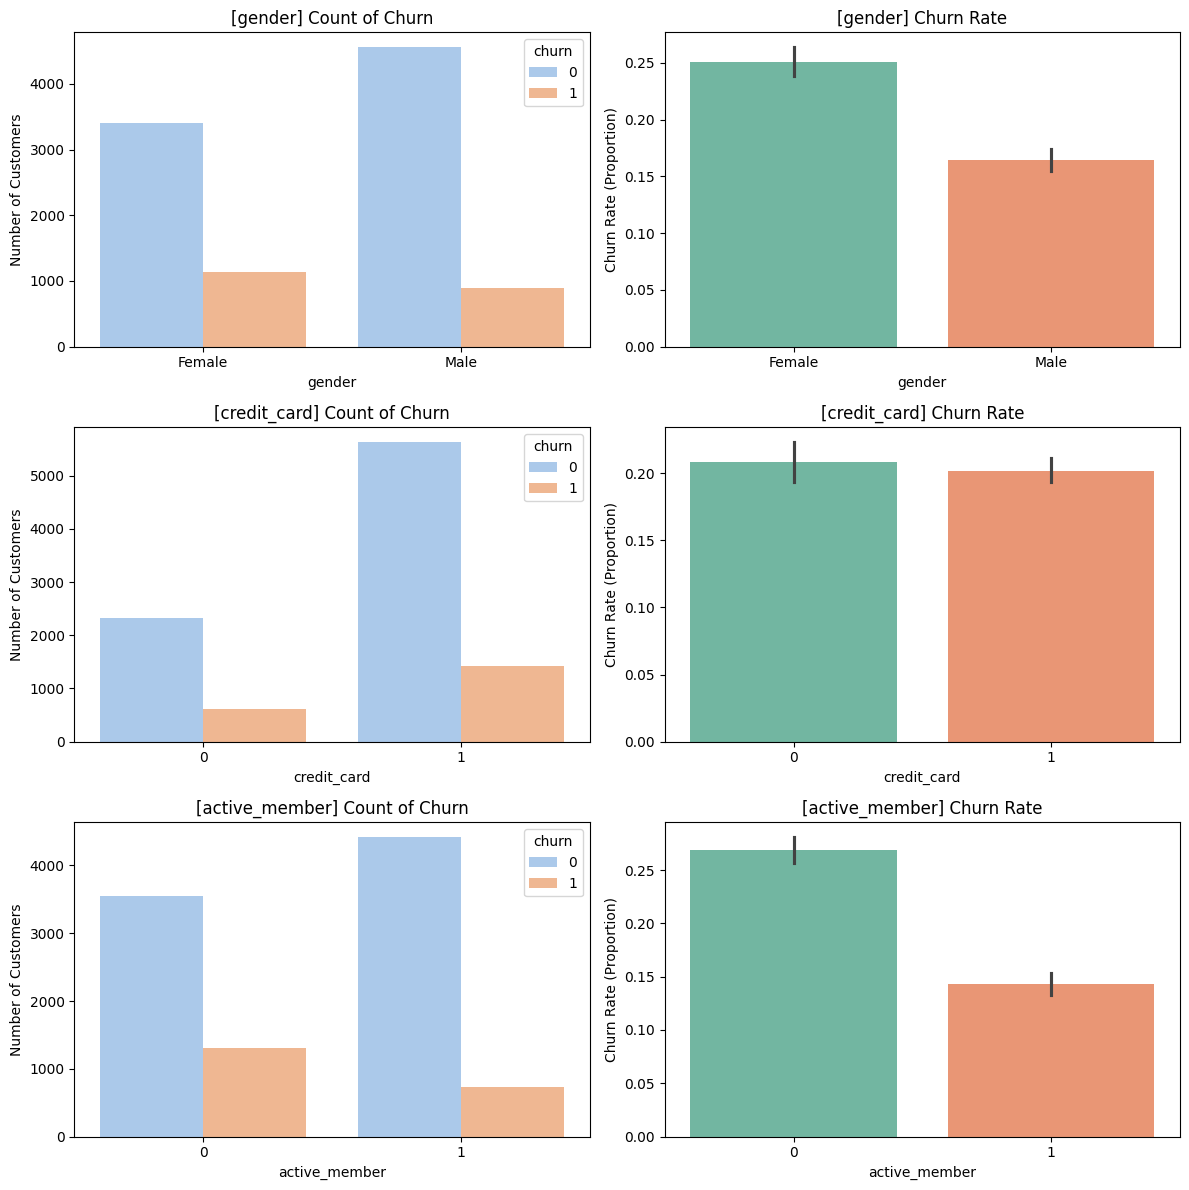

In [ ]:
# (2) 이변량 분석(범주형-수치형)-> 단순 시각화
cat_cols = ['gender', 'credit_card', 'active_member']

# 3행 2열 (가로 12, 세로 12 크기)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, col in enumerate(cat_cols):
    # [왼쪽 그래프] 절대적인 고객 수 (Countplot)
    # 이 그룹에 사람이 얼마나 많은지, 그중 이탈자(1)와 잔류자(0)의 규모 파악
    sns.countplot(x=col, hue='churn', data=df, ax=axes[i, 0], palette='pastel')
    axes[i, 0].set_title(f'[{col}] Count of Churn')
    axes[i, 0].set_ylabel('Number of Customers')
    
    # [오른쪽 그래프] 이탈률 (Barplot)
    sns.barplot(x=col, y='churn', data=df, ax=axes[i, 1], palette='Set2')
    axes[i, 1].set_title(f'[{col}] Churn Rate')
    axes[i, 1].set_ylabel('Churn Rate (Proportion)')

plt.tight_layout()
plt.show()

결과1: countplot 결과 모든 변수들은 성별 여부, 신용카드 보유 여부, 활성 고객 여부와 관계 없이 이탈X가 더 많음.  

비율 결과  

-성별: 그래프를 살펴본 결과, 여성이 남성보다 이탈율이 더 높고 신뢰구간 또한 겹치지 않으므로 두 집단 간에 차이가 있다고 볼 근거가 있다.  
-신용카드 보유 여부: 그래프를 살펴본 결과, 신용카드 여부와 이탈율 간의 관계에는 큰 차이가 보이지 않고 신뢰구간 또한 겹치므로 두 집단 간에 차이가 있다고 볼 근거는 부족하다.  
-활성 고객 여부: 그래프를 살펴본 결과, 비활성 고객이 활성 고객보다 이탈율이 더 높고 신뢰구간 또한 겹치지 않으므로 두 집단 간에 차이가 있다고 볼 근거가 있다.  

-> 성별(gender), 활성 고객 여부(active_member) 는 이탈율에 영향을 주는 핵심 변수일 가능성이 높음.

In [ ]:
# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
# 1. 필요 없는 컬럼 삭제
df=df.drop(columns=['customer_id'], errors='ignore') # 은행 이탈에 영향을 주는 변수가 아니기도 하고, 경우의 수가 매우 많으므로 삭제한다.
# 2. 결측치 처리(모든 칼럼이 결측치가 존재하지 않으므로 결측치 처리는 생략한다.)
# 3. 가변수화
df=pd.get_dummies(df, columns=['country', 'gender'], drop_first=True) # 범주형 데이터인 'country', 'gender'를 pd.get_dummies()를 활용해 가변수화 시켜준다. 또한 drop_first=True를 통해 하나만 처리해준다.

In [ ]:
# split
# PyCaret을 돌린다면 데이터를 X,y로 분할하고, 스케일링을 진행하는 과정을 생략할 수 있다.
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 12)"
4,Transformed data shape,"(8000, 12)"
5,Transformed train set shape,"(5600, 12)"
6,Transformed test set shape,"(2400, 12)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8625,0.8654,0.4655,0.7711,0.5786,0.5027,0.5265,0.1270
catboost,CatBoost Classifier,0.8589,0.8639,0.4760,0.7408,0.5780,0.4983,0.5167,0.8570
ada,Ada Boost Classifier,0.8550,0.8509,0.4716,0.7223,0.5690,0.4867,0.5035,0.0540
xgboost,Extreme Gradient Boosting,0.8475,0.8365,0.4891,0.6739,0.5653,0.4759,0.4857,0.0380
lightgbm,Light Gradient Boosting Machine,0.8530,0.8498,0.4689,0.7131,0.5637,0.4803,0.4966,0.1650
rf,Random Forest Classifier,0.8586,0.8423,0.4506,0.7569,0.5636,0.4860,0.5098,0.1010
et,Extra Trees Classifier,0.8514,0.8423,0.4164,0.7415,0.5323,0.4524,0.4795,0.0800
qda,Quadratic Discriminant Analysis,0.8362,0.8158,0.3865,0.6706,0.4886,0.3999,0.4222,0.0120
dt,Decision Tree Classifier,0.7857,0.6803,0.5023,0.4749,0.4876,0.3524,0.3530,0.0180
lda,Linear Discriminant Analysis,0.8088,0.7728,0.2393,0.5744,0.3371,0.2471,0.2798,0.0150


In [ ]:
# 1. gbc: Gradient Boosting Classifier
# 2. catboost: CatBoost Classifier
# 3. ada: Ada Boost Classifier
# 4. xgboost: Extreme Gradient Boosting

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)


# 4. 데이터 분할
X=df.drop('churn',axis=1)
y=df['churn']

X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=42, stratify=df['churn']) # 데이터를 8:2로 분할한다.
# 5. 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid) # 값의 범위를 일치시키기 위해서 표준화 스케일링을 진행해 평균을 0으로 표준편차를 1로 맞춰줌
import optuna
from sklearn.metrics import f1_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def objective_gbc(trial): # Gradient Boosting 분류 모델
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300), # 트리 개수(100~300)
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 트리 깊이(3~15)
    }
    model = GradientBoostingClassifier(**params) # Optuna가 무작위로 고른 그 설정값으로  GradientBoosting 모델을 만들라는 뜻
    model.fit(X_train, y_train) # 그 모델로 학습을 시키고

    pred = model.predict(X_valid) # X_valid로 정답을 예측
    return f1_score(y_valid, pred) # 최종적으로 예측값과 실제 정답을 보고 결과 f1_score 반환

def objective_catboost(trial): # catboost 모델
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500), # 캣부스트는 iterations 사용(100~500개로 설정)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # 학습률을 0.01~0.3 정도로 정함
        'depth': trial.suggest_int('depth', 4, 10) # 깊이를 4~10 으로 정함
    }
    # verbose=0을 주어야 학습할 때마다 쓸데없는 로그가 화면을 덮는 것을 방지할 수 있음
    model = CatBoostClassifier(**params, random_state=42, verbose=0) 
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_ada(trial): # adaboost 모델
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 2.0) # 아다부스트는 깊이 조절 대신 주로 학습률과 트리 개수로 승부
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_xgboost(trial): # xgboost 모델
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) # 데이터의 일부만 뽑아서 학습해 과적합 방지
    }
    model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)


# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10) # 아무 숫자나 10번 넣어서 테스트해 보고,
# 제일 점수 높게 나오는 설정값을 알려달라는 뜻

study_catboost = optuna.create_study(direction='maximize')
study_catboost.optimize(objective_catboost, n_trials=10)

study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

study_xgboost = optuna.create_study(direction='maximize')
study_xgboost.optimize(objective_xgboost, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
gbc_best = GradientBoostingClassifier(**study_gbc.best_params) # 옵튜나가 찾아낸 가장 좋은 설정값으로 진짜 모델들 생성
catboost_best = CatBoostClassifier(**study_catboost.best_params, verbose=0)
ada_best = AdaBoostClassifier(**study_ada.best_params)
xgboost_best = XGBClassifier(**study_xgboost.best_params)

# 모델 학습
gbc_best.fit(X_train, y_train)
catboost_best.fit(X_train, y_train)
ada_best.fit(X_train, y_train)
xgboost_best.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('GBC', gbc_best), ('CatBoost', catboost_best), ('AdaBoost', ada_best), ('XGBoost', xgboost_best)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

[I 2026-04-09 16:10:03,550] A new study created in memory with name: no-name-b9426ea1-d90e-4274-bcc9-bc94a35156e4
[I 2026-04-09 16:10:15,286] Trial 0 finished with value: 0.5479041916167665 and parameters: {'n_estimators': 285, 'max_depth': 8}. Best is trial 0 with value: 0.5479041916167665.
[I 2026-04-09 16:10:54,826] Trial 1 finished with value: 0.554364471669219 and parameters: {'n_estimators': 266, 'max_depth': 15}. Best is trial 1 with value: 0.554364471669219.
[I 2026-04-09 16:11:01,920] Trial 2 finished with value: 0.5481927710843374 and parameters: {'n_estimators': 209, 'max_depth': 7}. Best is trial 1 with value: 0.554364471669219.
[I 2026-04-09 16:11:11,513] Trial 3 finished with value: 0.5667655786350149 and parameters: {'n_estimators': 239, 'max_depth': 6}. Best is trial 3 with value: 0.5667655786350149.
[I 2026-04-09 16:11:16,987] Trial 4 finished with value: 0.5963855421686747 and parameters: {'n_estimators': 152, 'max_depth': 5}. Best is trial 4 with value: 0.59638554216

GBC F1: 0.5921450151057401
CatBoost F1: 0.6060606060606061
AdaBoost F1: 0.5809248554913294
XGBoost F1: 0.5946745562130178


# 결과  
최종 F1_score를 보면 CatBoost가 1등을 한 것을 확인할 수 있음.

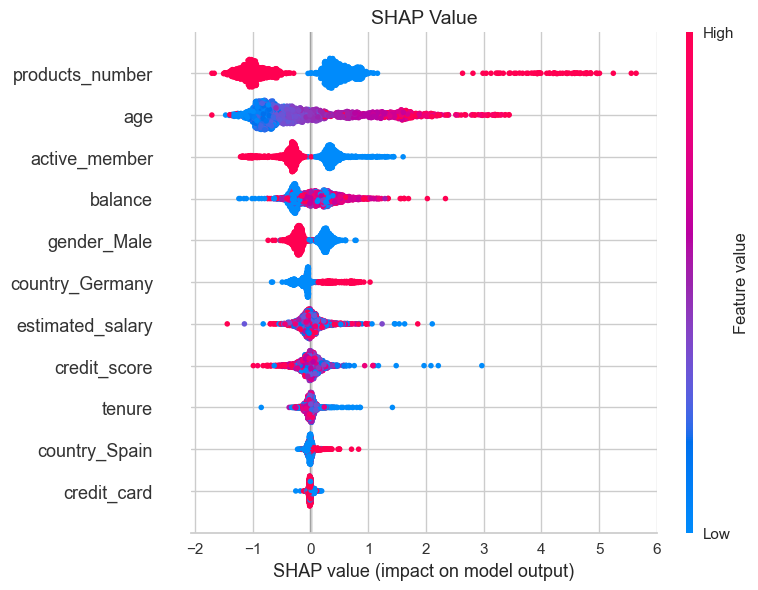

In [10]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(gbc_best)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()

# SHAP value 사후 분석 결과  
1. products_number(상품 보유 수): 빨간색 점이 왼쪽에도 존재하지만, 오른쪽에도 길게 뻗어 있는 것을 확인해 볼 수 있다. 이는 상품 보유가 3개 이상인 고객이 이탈율이 높은 것을 확인해 볼 수 있다.  
2. age(나이): 나이가 많은 빨간색 점이 오른쪽으로 길게 뻗어 있는 것으로 보아, 나이가 많을수록 이탈율이 높은 것을 확인해 볼 수 있다.(앞서 EDA에서 확인 결과와 일치함)  
3. activate_member(활성 고객 여부), gender_Male(남성): 비활성고객일수록, 여성일수록 이탈율이 높은 것을 확인해 볼 수 있다.(앞서 EDA에서 확인 결과와 일치함)  
4. balance(계좌 잔액): 빨간색 점이 오른쪽으로 길게 뻗어 있는 것으로 보아, 계좌 잔액이 많은 고객이 이탈율이 높은 것을 확인해 볼 수 있다.-> 중요  
5. country_Germany, Spain: 독일사람일수록, 스페인사람일수록 이탈율이 높은 것을 확인해 볼 수 있다.

# 인사이트  
1. products_number(상품 보유 수): 상품을 오히려 더 많이 보유(3개 이상)한 고객의 이탈율이 높다. 이는 적당히 보유(0~2개)한 고객보다 상품을 많이 보유한 것이 대출금리 부담 등의 이유로 떠나갔을 가능성이 있다고 생각된다.  
2. age(나이): 나이가 많을수록 이탈율이 높다. 이는 노인 고객들이 이 은행을 이용하기에 어려움을 느꼈을 가능성이 크다고 생각된다. 노인들은 인터넷뱅킹, 모바일뱅킹 등의 최신 기술에 뒤쳐져 있으므로 이들을 따로 관리해줄 수 있는 방법이 필요하다고 판단된다.  
3. activate_member(활성 고객 여부), gender_Male(남성): 여성일수록 이탈율이 높다. 이는 여성 고객들을 대상으로한 상품들이 큰 매력을 가지고 있지 않다고 생각된다. 여성들도 본 은행을 이용할 만한 메리트가 있어야 된다고 느낄만한 상품을 출시하거나 기존의 상품들을 조금 수정해볼 필요성이 있다고 생각된다.  
또한, 비활성 고객일수록 이탈율이 높으므로 휴먼 상태인 고객들을 다시 끌어들일 만한 매력 있는 상품을 제안하거나 하는 등의 필요성이 있어야 한다고 생각된다.  
4. balance(계좌 잔액): 계좌 잔액이 많을수록 이탈율이 높은 경향이 보인다. 돈이 많은데도 불구하고 이탈율이 높다는 것은 타행의 매력도가 더 크게 느껴져서 떠나갈 수 있다고 생각된다. 타행의 금리 혜택이 더 크거나 하는 등의 이유가 있을 수 있겠다.  
5. country_Germany, Spain: 특정한 나라에서 이탈율이 더 높다는 것은 그 나라에 있는 본 은행이 문제가 있어서 일수도 있다고 생각된다. 즉각적인 조치를 취해야 할 필요성이 있다.

In [11]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) f1_score(57정도), accuracy_score(80정도) 출력
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print("\n Stacking 앙상블 학습 시작")

# 1. Base Models (전방 모델)
estimators = [
    ('GBC', gbc_best),
    ('CatBoost', catboost_best),
    ('AdaBoost', ada_best),
    ('XGBoost', xgboost_best)
]

# 2. Meta Model (후방 모델): 
# 부스팅 모델들을 메타로 쓰면 과적합이 잘 일어나서, 선형 모델을 사용
meta_model = LogisticRegression()

# 3. Stacking 모델 정의
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5, # 내부 교차검증 5번
    n_jobs=-1 
)

# 4. 학습 및 예측
stacking_clf.fit(X_train, y_train)
stack_pred = stacking_clf.predict(X_valid)

# 5. 최종 결과 확인
stacking_f1 = f1_score(y_valid, stack_pred)
print(f"최종 Stacking F1 Score: {stacking_f1:.4f}")


 Stacking 앙상블 학습 시작
최종 Stacking F1 Score: 0.6080
